In [ ]:
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, classification_report, accuracy_score, confusion_matrix
import warnings; warnings.filterwarnings('ignore')

In [ ]:
bc = load_breast_cancer(); X = bc.data; y = bc.target

# Task 1
### Train-Validation Split
- Split the data into training (80%) and validation (20%) sets using `train_test_split()` with `random_state = 9001` for reproducibility

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 9001)

# Task 2
### Data Scaling
- Scale the features using `MinMaxScaler()`
- Remeber to scale the training data with `fit_transform()` and the validation data only with `transform()` once the scaler has been fit

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Task 3
### Unregularised Logistic Regression Model
- Train a logistic regression model using `LogisticRegression()` from `sklearn` with `solver = 'saga'`, `random_state = 42`, and `max_iter = 1000` on the scaled training data
- Ensure that `C = np.inf` is used so that you obtain an unregularised model

In [ ]:
model_no_reg = LogisticRegression(penalty = None, solver = 'saga', random_state = 42, max_iter = 1000, C = np.inf)
model_no_reg.fit(X_train_scaled, y_train)

LogisticRegression(C=inf, max_iter=1000, penalty=None, random_state=42,
                   solver='saga')

# Task 4
### Regularised Logistic Regression Models
- Train an L1-regularised logistic regression model using `LogisticRegression()` from `sklearn` with `solver = 'saga'`, `random_state = 42`, `max_iter = 1000`, `l1_ratio = 1.0`, and `C = 0.1` on the scaled training data
- Perform hyperparameter tuning for L1-regularised (`l1_ratio = 1.0`) logistic regression using `GridSearchCV()` with $\text{C} \in \{0.05, 0.1, 1.15\}$, `cv = 5`, `scoring = 'accuracy'`, with same values for `solver`, `random_state`, and `max_iter` as before, and fit it on the scaled training data
- Train an L2-regularised logistic regression model using `LogisticRegression()` from `sklearn` with `solver = 'saga'`, `random_state = 42`, `max_iter = 1000`, `l1_ratio = 0.0`, and `C = 0.1` on the scaled training data
- Perform hyperparameter tuning for L2-regularised (`l1_ratio = 0.0`) logistic regression using `GridSearchCV()` with $\text{C} \in \{0.05, 0.1, 1.15\}$, `cv = 5`, `scoring = 'accuracy'`, with same values for `solver`, `random_state`, and `max_iter` as before, and fit it on the scaled training data

In [ ]:
model_l1 = LogisticRegression(penalty = 'l1', l1_ratio = 1.0, C = 0.1, solver = 'saga', random_state = 42, max_iter = 1000)
model_l1.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, l1_ratio=1.0, max_iter=1000, penalty='l1',
                   random_state=42, solver='saga')

In [ ]:
param_grid = {'C': [0.05, 0.1, 0.15]}

In [ ]:
tuned_model_l1 = LogisticRegression(penalty = 'l1', l1_ratio = 1.0, solver = 'saga', random_state = 42, max_iter = 1000)
grid_l1 = GridSearchCV(estimator = tuned_model_l1, param_grid = param_grid, scoring = 'accuracy', cv = 5)
grid_l1.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(l1_ratio=1.0, max_iter=1000,
                                          penalty='l1', random_state=42,
                                          solver='saga'),
             param_grid={'C': [0.05, 0.1, 0.15]}, scoring='accuracy')

In [ ]:
model_l2 = LogisticRegression(penalty = 'l2', l1_ratio = 0.0, C = 0.1, solver = 'saga', random_state = 42, max_iter = 1000)
model_l2.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, l1_ratio=0.0, max_iter=1000, random_state=42,
                   solver='saga')

In [ ]:
tuned_model_l2 = LogisticRegression(penalty = 'l2', l1_ratio = 0.0, solver = 'saga', random_state = 42, max_iter = 1000)
grid_l2 = GridSearchCV(estimator = tuned_model_l2, param_grid = param_grid, scoring = 'accuracy', cv = 5)
grid_l2.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(l1_ratio=0.0, max_iter=1000,
                                          random_state=42, solver='saga'),
             param_grid={'C': [0.05, 0.1, 0.15]}, scoring='accuracy')

# Task 5
### Model Performance
- Generate a classification report on the validation data for all the following five models using `classification_report()` from `sklearn`
  - Unregularised model
  - L1-regularised model with $\text{C} = 0.1$
  - Best L1-regularised model after tuning for C (use the `best_estimator_` attribute of the trained grid model)
  - L2-regularised model with $\text{C} = 0.1$
  - Best L2-regularised model after tuning for C (use the `best_estimator_` attribute of the trained grid model)
- Also compare the training and validation accuracies of all these models using `accuracy_score()` from `sklearn`
- Also compare the training and validation sensitivities (positive recall) of all these models using `recall_score()` from `sklearn` with `pos_label = 1`
- Generate confusion matrices for the training and validation datasets for all the trained logistic regression models using `confusion_matrix()` from `sklearn`. Use the class labels obtained from the `predict()` method and visualise the confusion matrices to compare the model predictions across the unregularised, L1-regularised, L2-regularised, and tuned models.

In [ ]:
y_pred = model_no_reg.predict(X_val_scaled); print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        42
           1       1.00      0.97      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
y_pred = model_l1.predict(X_val_scaled); print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        42
           1       0.92      1.00      0.96        72

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
y_pred = grid_l1.best_estimator_.predict(X_val_scaled); print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        42
           1       0.92      1.00      0.96        72

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
y_pred = model_l2.predict(X_val_scaled); print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
y_pred = grid_l2.best_estimator_.predict(X_val_scaled); print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        42
           1       0.95      1.00      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
def plot_confusion_matrices(y_train, y_train_pred, y_val, y_val_pred, model_name):
    cm_train = confusion_matrix(y_train, y_train_pred); cm_val = confusion_matrix(y_val, y_val_pred)
    fig, axes = plt.subplots(1, 2, figsize = (10, 4))
    axes[0].imshow(cm_train, cmap = 'Blues'); axes[0].set_title('Training')
    axes[0].set_xlabel('Predicted label'); axes[0].set_ylabel('True label')
    for i in range(cm_train.shape[0]):
        for j in range(cm_train.shape[1]):
            axes[0].text(j, i, cm_train[i, j], ha = 'center', va = 'center', color = 'black')
    axes[1].imshow(cm_val, cmap = 'Blues'); axes[1].set_title('Validation')
    axes[1].set_xlabel('Predicted label'); axes[1].set_ylabel('True label')
    for i in range(cm_val.shape[0]):
        for j in range(cm_val.shape[1]):
            axes[1].text(j, i, cm_val[i, j], ha = 'center', va = 'center', color = 'black')
    axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1]); axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
    fig.suptitle(model_name); plt.tight_layout(); plt.show()

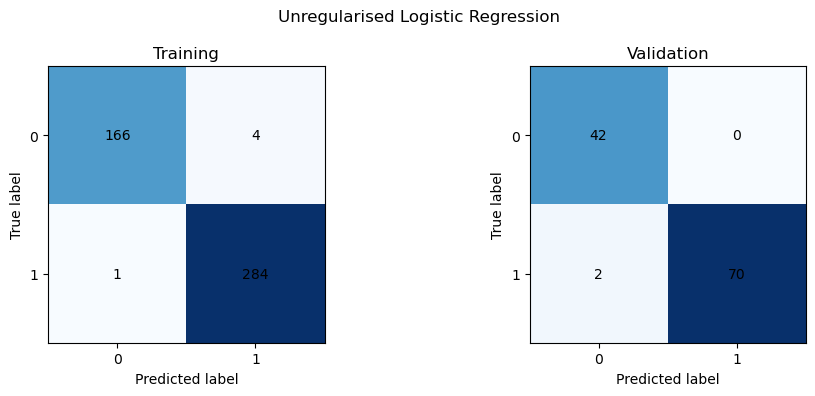

In [ ]:
plot_confusion_matrices(y_train, model_no_reg.predict(X_train_scaled), y_val, model_no_reg.predict(X_val_scaled), 'Unregularised Logistic Regression')

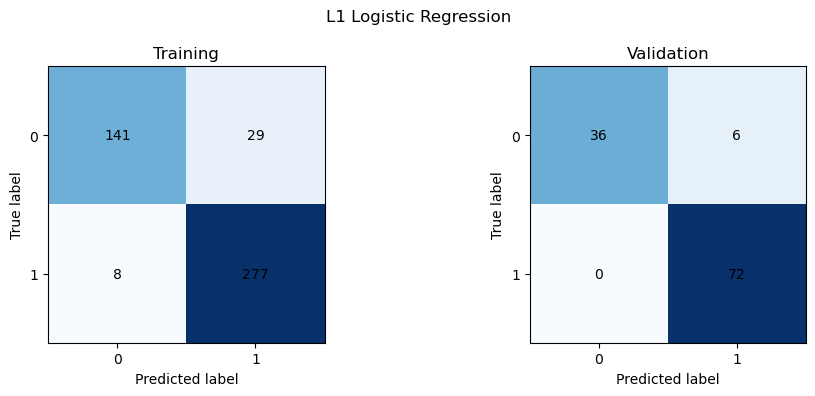

In [ ]:
plot_confusion_matrices(y_train, model_l1.predict(X_train_scaled), y_val, model_l1.predict(X_val_scaled), 'L1 Logistic Regression')

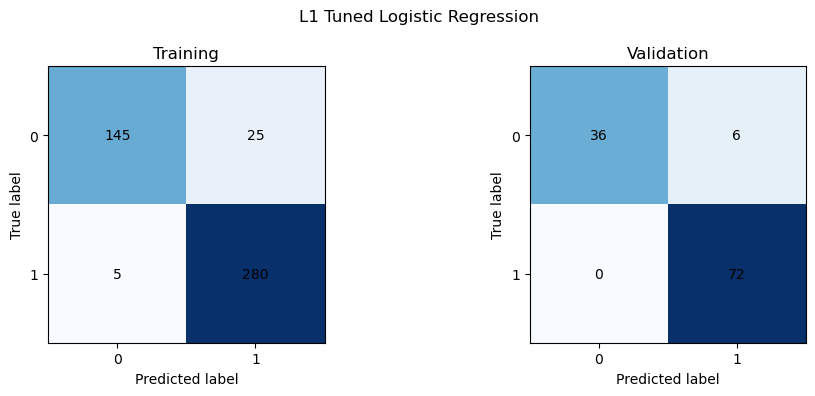

In [ ]:
plot_confusion_matrices(y_train, grid_l1.predict(X_train_scaled), y_val, grid_l1.predict(X_val_scaled), 'L1 Tuned Logistic Regression')

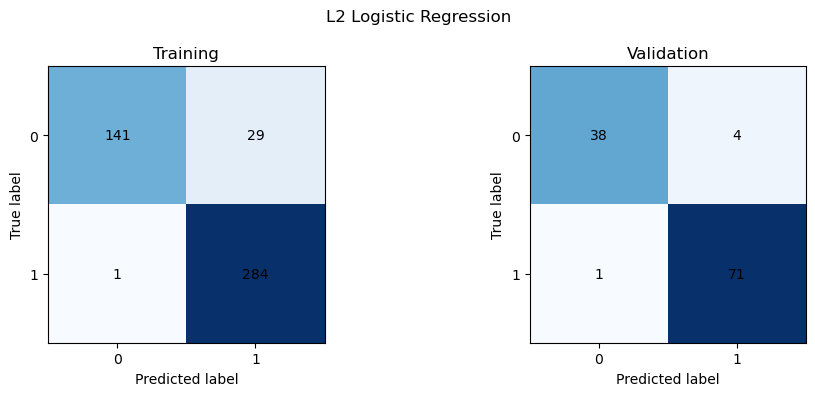

In [ ]:
plot_confusion_matrices(y_train, model_l2.predict(X_train_scaled), y_val, model_l2.predict(X_val_scaled), 'L2 Logistic Regression')

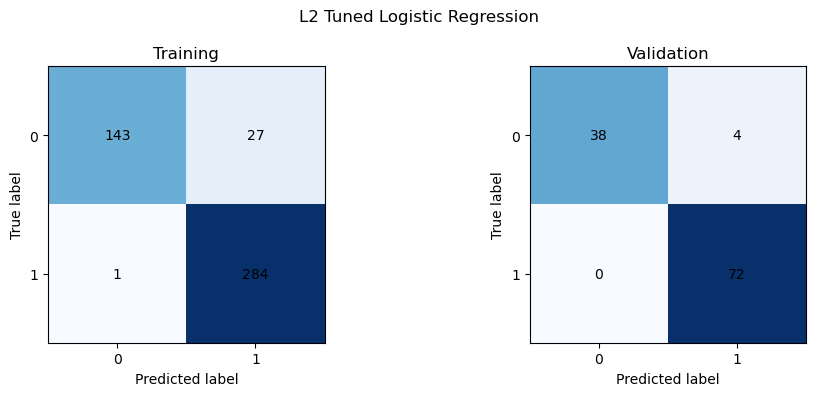

In [ ]:
plot_confusion_matrices(y_train, grid_l2.predict(X_train_scaled), y_val, grid_l2.predict(X_val_scaled), 'L2 Tuned Logistic Regression')

In [ ]:
print('Unregularised model')
print('Train Sensitivity = {}'.format(recall_score(y_train, model_no_reg.predict(X_train_scaled), pos_label = 1)))
print('Val Sensitivity = {}'.format(recall_score(y_val, model_no_reg.predict(X_val_scaled), pos_label = 1)))
print('\n')
print('L1-regularised model with C = 0.1')
print('Train Sensitivity = {}'.format(recall_score(y_train, model_l1.predict(X_train_scaled), pos_label = 1)))
print('Val Sensitivity = {}'.format(recall_score(y_val, model_l1.predict(X_val_scaled), pos_label = 1)))
print('\n')
print('Best L1-regularised model')
print('Train Sensitivity = {}'.format(recall_score(y_train, grid_l1.best_estimator_.predict(X_train_scaled), pos_label = 1)))
print('Val Sensitivity = {}'.format(recall_score(y_val, grid_l1.best_estimator_.predict(X_val_scaled), pos_label = 1)))
print('\n')
print('L2-regularised model with C = 0.1')
print('Train Sensitivity = {}'.format(recall_score(y_train, model_l2.predict(X_train_scaled), pos_label = 1)))
print('Val Sensitivity = {}'.format(recall_score(y_val, model_l2.predict(X_val_scaled), pos_label = 1)))
print('\n')
print('Best L2-regularised model')
print('Train Sensitivity = {}'.format(recall_score(y_train, grid_l2.best_estimator_.predict(X_train_scaled), pos_label = 1)))
print('Val Sensitivity = {}'.format(recall_score(y_val, grid_l2.best_estimator_.predict(X_val_scaled), pos_label = 1)))

Unregularised model
Train Sensitivity = 0.9964912280701754
Val Sensitivity = 0.9722222222222222


L1-regularised model with C = 0.1
Train Sensitivity = 0.9719298245614035
Val Sensitivity = 1.0


Best L1-regularised model
Train Sensitivity = 0.9824561403508771
Val Sensitivity = 1.0


L2-regularised model with C = 0.1
Train Sensitivity = 0.9964912280701754
Val Sensitivity = 0.9861111111111112


Best L2-regularised model
Train Sensitivity = 0.9964912280701754
Val Sensitivity = 1.0


In [ ]:
print('Unregularised model')
print('Train Acc = {}'.format(accuracy_score(y_train, model_no_reg.predict(X_train_scaled))))
print('Val Acc = {}'.format(accuracy_score(y_val, model_no_reg.predict(X_val_scaled))))
print('\n')
print('L1-regularised model with C = 0.1')
print('Train Acc = {}'.format(accuracy_score(y_train, model_l1.predict(X_train_scaled))))
print('Val Acc = {}'.format(accuracy_score(y_val, model_l1.predict(X_val_scaled))))
print('\n')
print('Best L1-regularised model')
print('Train Acc = {}'.format(accuracy_score(y_train, grid_l1.best_estimator_.predict(X_train_scaled))))
print('Val Acc = {}'.format(accuracy_score(y_val, grid_l1.best_estimator_.predict(X_val_scaled))))
print('\n')
print('L2-regularised model with C = 0.1')
print('Train Acc = {}'.format(accuracy_score(y_train, model_l2.predict(X_train_scaled))))
print('Val Acc = {}'.format(accuracy_score(y_val, model_l2.predict(X_val_scaled))))
print('\n')
print('Best L2-regularised model')
print('Train Acc = {}'.format(accuracy_score(y_train, grid_l2.best_estimator_.predict(X_train_scaled))))
print('Val Acc = {}'.format(accuracy_score(y_val, grid_l2.best_estimator_.predict(X_val_scaled))))

Unregularised model
Train Acc = 0.989010989010989
Val Acc = 0.9824561403508771


L1-regularised model with C = 0.1
Train Acc = 0.9186813186813186
Val Acc = 0.9473684210526315


Best L1-regularised model
Train Acc = 0.9340659340659341
Val Acc = 0.9473684210526315


L2-regularised model with C = 0.1
Train Acc = 0.9340659340659341
Val Acc = 0.956140350877193


Best L2-regularised model
Train Acc = 0.9384615384615385
Val Acc = 0.9649122807017544


# Task 6
### Model Coefficients
- Extract feature coefficients and intercept terms for all the five models and compare them across features

In [ ]:
feature_names = bc.feature_names
coef_comparison = pd.DataFrame({'Feature': feature_names,
                                'NoReg': model_no_reg.coef_[0],
                                'L1C0.1': model_l1.coef_[0],
                                'L1bestC': grid_l1.best_estimator_.coef_[0],
                                'L2C0.1': model_l2.coef_[0],
                                'L2bestC': grid_l2.best_estimator_.coef_[0],})
coef_comparison.set_index('Feature', inplace = True)
coef_comparison.loc['Intercept'] = [model_no_reg.intercept_[0],
                                    model_l1.intercept_[0],
                                    grid_l1.best_estimator_.intercept_[0],
                                    model_l2.intercept_[0],
                                    grid_l2.best_estimator_.intercept_[0],]
coef_comparison

,NoReg,L1C0.1,L1bestC,L2C0.1,L2bestC
Feature,,,,,
mean radius,2.774013,0.000000,0.000000,-0.761259,-0.904885
mean texture,0.461502,0.000000,0.000000,-0.492768,-0.620597
mean perimeter,2.689274,0.000000,0.000000,-0.766798,-0.908549
mean area,-0.895888,0.000000,0.000000,-0.643312,-0.761831
mean smoothness,-2.449629,0.000000,0.000000,-0.262974,-0.308437
mean compactness,11.254975,0.000000,0.000000,-0.442111,-0.481693
mean concavity,-6.378838,0.000000,0.000000,-0.695141,-0.798449
mean concave points,-10.605046,0.000000,-0.272629,-0.948497,-1.116288
mean symmetry,0.932982,0.000000,0.000000,-0.271225,-0.312638
